In [28]:
import xarray as xr
import netCDF4 as nc
import numpy as np
from process_dataset_for_training import (
    reshape_data,
    downsample_in_time,
    create_parameter_component
)

import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [3]:
file = '/cluster/work/math/vogtva/data/bruss/ball_big/_dataset.nc'
ds = xr.open_dataset(file)
ds = ds.chunk({"run": 100, "snapshot": 10, "x_size_and_boundary": 10, "n_coupled_and_y_size_and_boundary": 10})

In [4]:
ds = ds.isel(run=range(0,10))

In [5]:
resh_data = reshape_data(ds)

/cluster/home/vogtva/pde-data-gen/scripts/process_dataset_for_training.py:32: UserWarning: rename 'x_size_and_boundary' to 'Nx' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ).rename({"x_size_and_boundary": "Nx", "n_coupled_and_y_size_and_boundary": "Ny"})
/cluster/home/vogtva/pde-data-gen/scripts/process_dataset_for_training.py:32: UserWarning: rename 'n_coupled_and_y_size_and_boundary' to 'Ny' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ).rename({"x_size_and_boundary": "Nx", "n_coupled_and_y_size_and_boundary": "Ny"})
/cluster/home/vogtva/pde-data-gen/scripts/process_dataset_for_training.py:36: UserWarning: rename 'x_size_and_boundary' to 'Nx' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ).rename({"x_size_and_boundary": "Nx", "n_coupled_and_y

In [6]:
resh_data = downsample_in_time(resh_data, 10)

In [7]:
ds_new = xr.Dataset(
    data_vars={
        "data": resh_data,
        "A": ds["A"],
        "B": ds["B"],
        "Du": ds["Du"],
        "Dv": ds["Dv"],
    }
)

In [9]:
param_component = create_parameter_component(ds_new)
param_component = param_component.expand_dims(dim="component").assign_coords(
    component=["param"]
)

data_with_param = xr.concat([ds_new["data"], param_component], dim="component")

In [10]:
ds_final = xr.Dataset(
    data_vars={
        "data": data_with_param,
        "A": ds["A"],
        "B": ds["B"],
        "Du": ds["Du"],
        "Dv": ds["Dv"],
    }
)
ds_final.rename({"run": "trajectory"})
# At this point, no computation has been done yet
# To actually compute and save the result:
# ds_final.to_netcdf("res.nc")

<xarray.Dataset> Size: 20MB
Dimensions:     (Nx: 128, Ny: 128, component: 3, trajectory: 10, snapshot: 10)
Coordinates:
    Nx          (Nx) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
    Ny          (Ny) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * component   (component) <U5 60B 'u' 'v' 'param'
  * trajectory  (trajectory) int64 80B 0 1 2 3 4 5 6 7 8 9
  * snapshot    (snapshot) int64 80B 0 1 2 3 4 5 6 7 8 9
Data variables:
    data        (trajectory, snapshot, component, Nx, Ny) float32 20MB dask.array<chunksize=(10, 10, 1, 9, 4), meta=np.ndarray>
    A           (trajectory) float32 40B dask.array<chunksize=(10,), meta=np.ndarray>
    B           (trajectory) float32 40B dask.array<chunksize=(10,), meta=np.ndarray>
    Du          (trajectory) float32 40B dask.array<chunksize=(10,), meta=np.ndarray>
    Dv          (trajectory) float32 40B dask.array<chunksize=(10,), meta=np.ndarray>

In [55]:
run = 0

In [56]:
for var in ["A", "B", "Du", "Dv"]:
    print(var, " = ", np.array(ds_final[var].isel(run=run)).item())

A  =  5.491498947143555
B  =  5.924652576446533
Du  =  1.0375524759292603
Dv  =  10.316274642944336


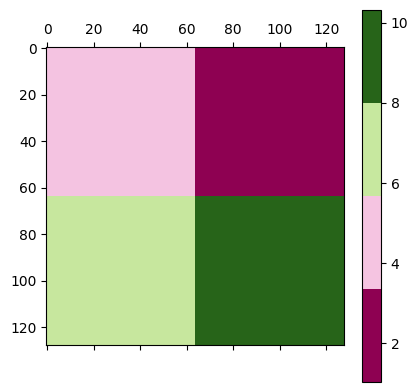

In [57]:
cmap = plt.get_cmap('PiYG', 4)
plt.matshow(ds_final.data.isel(run=run, snapshot=0, component=2), cmap=cmap)
plt.colorbar()
plt.show()

In [3]:
import h5py
import zarr

In [5]:
reader = zarr.open('/cluster/work/math/vogtva/data/bruss/param_sweep/_dataset_proc.zarr/')

/cluster/home/vogtva/.local/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
